# MPW2 - Computational graphs

In [1]:
import random
import pandas as pd
import numpy as np
from graphql import ValueNode
from numpy.linalg import inv
import matplotlib.pyplot as plt
from cgnodes import *

In this notebook, spot the **TO_COMPLETE** comments in the code and in the markdown cells. Don't hesitate to add your own code and markdown cells to complete the exercises. You can also add comments in the code to explain your reasoning.

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](../images/simple-graph-1.jpg)

In [2]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0

f = 64.0


## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [3]:
datafile = "../data/lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [4]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [5]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend, 
# also optional.
def plot_data_prediction(
        x_points,
        y_points,
        x_curve=None,
        y_curve=None,
        x_title='x',
        y_title='y',
        theta_0=None,
        theta_1=None,
        theta_2=None):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)   # ex "Living area (m^2)"
    plt.ylabel(y_title)   # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = fr"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += fr", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

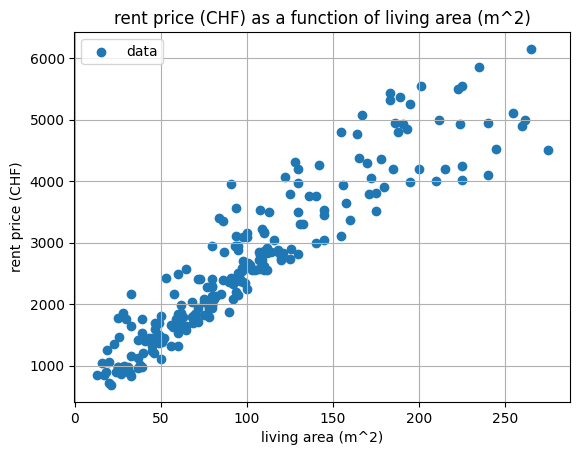

In [6]:
plot_data_prediction(living_area, rent_price, x_title='living area (m^2)', y_title='rent price (CHF)')

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}

intercept (theta_0): 657.6890591150313
slope (theta_1)    : 19.661179947454315


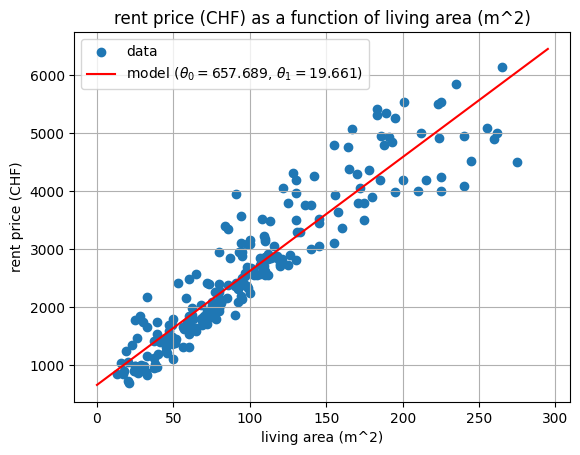

In [7]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
# According to formula in the markdown just above
# expected is Theta = Inverted (X Transposed multiplied X ) multiplied X Transposed multiplied Y
theta = np.linalg.inv(X.T @ X) @ X.T @ y

print("intercept (theta_0):", theta[0])  # should be around 658
print("slope (theta_1)    :", theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title='living area (m^2)',
    y_title='rent price (CHF)',
    theta_0=theta[0],
    theta_1=theta[1],
)

The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :

In [8]:
def mse_loss(y_hat, y):
    #get number of elements, i need it for get mean
    N = len(y)
    # I need the sum of all errors squared , so (y_hat -Y) power 2
    Sum = np.sum((y_hat - y)**2)
    # now divide by 2 same s in formula
    MSE = Sum / (2*N)
    return MSE


y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  # should be around 105K

The total value of the loss is 104915.13056913581


This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression). Another frequently used metric is the root mean squared error (RMSE) which is the square root of the MSE. It is in the same unit as the target variable and is easier to interpret. Other commonly used metrics are the mean absolute error (MAE) and the mean absolute percentage error (MAPE). MAE is the average of the absolute  differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE. MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

## Formulas for RMSE , MAE, MAPE
### Root Mean Squared Error (RMSE)

\begin{equation*}
	RMSE = \sqrt{\frac{1}{N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}}
\end{equation*}


### Mean Absolute Error (MAE)

\begin{equation*}
	MAE = \frac{1}{N} \sum_{n=1}^{N} |\hat{y}_{n} - y_{n}|
\end{equation*}

### Mean Absolute Percentage Error (MAPE)

\begin{equation*}
	MAPE = \frac{1}{N} \sum_{n=1}^{N} \left|\frac{\hat{y}_{n} - y_{n}}{y_{n}}\right|
\end{equation*}


In [9]:
def rmse_loss(y_hat, y):
    #get number of elements, i need it for division
    N = len(y)

    # I need the sum of all errors squared , so (y_hat -Y) power 2
    Sum = np.sum((y_hat - y)**2)

    # times 1/N
    preResult = Sum * (1/N)

    # now squareroot of preresult
    RMSE = np.sqrt(preResult)
    return RMSE



def mae_loss(y_hat, y):
    #get number of elements, i need it for division
    N = len(y)

    # I need the sum of all absolute errors , so absolute values of (y_hat -Y)
    SumAbsVals = np.sum(np.abs((y_hat - y)))

    # times 1/N as in formula
    MAE = SumAbsVals * (1/N)
    return MAE

def mape_loss(y_hat, y):
    # This is almost same as MAE, but additionally to the sum of absolute errors, we divide this operation also by y, the real value

    #get number of elements, i need it for division
    N = len(y)

    # I need the sum of all absolute errors , so absolute values of (y_hat -Y)
    SumAbsValsDiv = np.sum(np.abs(((y_hat - y)/y)))

    # times 1/N as in formula
    MAPE = SumAbsValsDiv * (1/N)
    return MAPE

rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{mape_percent:.1f}%")

The total value of the RMSE loss is 458
The total value of the MAE loss is 347
The total value of the MAPE loss is 14.6%


TO COMPLETE : Implement the functions above to compute the MSE, RMSE, MAE and MAPE losses. Compute these losses for the linear regression model with the optimal $\theta$ obtained above. Interpret the results.

### Results for loss MSE, RMSE, MAE, MAPE

* **MSE = 104915**
    The mean squared error shows the mean squared difference of the predicted value minus the real value. This is quite high due to some big errors. The squared error is overly affected by some big outliers. Those can be seen in the following plot. The red lines indicate values which are less frequent and more distant to the regression line. Those outliers are points which can have a high influence on the model as they are far out, but they are still used for the model.
    * Outlier is a point with a high residual, absolute difference to the regression line.
    * ![Regression Plot](../images/Outlier.png)

* **RMSE = 458 CHF**
    The RMSE value is showing how much the predicted rent price differs from the true price on average. This is 458CHF.
    This indicates that the Error for a rent is quite off in general, however according to the plot the lower rents are somewhat well matched. This is because one can see the regression line closely matching the general trend of the measurements.

* **MAE = 347 CHF**
    The MAE is at 347CHF, lower than RMSE which squares the errors. This indicates that some large prediction errors influence the model strongly. This is figured by the lower MAE compared to RMSE, the MAE is influenced less by the large errors as it does not square and only takes the absolute difference.

* **MAPE = 14.6%**
    The MAPE of 14.6% indicate that on average the predictions differ by 14.6% to the measurements. Considering that we only use one predictor variable, this is quite good. However, it is only the mean error. In the plot one can see that the trend of the measurements is quite nicely matched at lower values (bottom left square), but at increasing sizes of values they differ more(top right square).
    *   ![Regression Plot](../images/Errors_Low_High.png)

* **Extra question: What could be the problem with MAPE ?**
    The Problem with MAPE, is that the predictions are good in some area, while they are getting worse in another area. In fact the distribution of the measurements indicates that a higher level regression rather then a linear regression could return better results. In the second top square the values are no longer linearly distributed, but are flattening down, thus a curve bending down could be better.
    * The issue is, that in the previously shown plot, it is observed that bottom left is nicely matched by the linear regression line.
    * However the top right square shows that the errors are growing with the higher measurements
    * While the mean percentual error is at 14.6% in general, it could be lower in the first section, and much higher in the top section, where the model struggles to match the datasets structure.

## Overall model quality

Overall this model captures the relation between living area and rentprice somewhat.
However as the model is very simple, it does not factor in other  important factors such as the age of the item. How far it is from the city or public transport and shops. Thus the difference in price per living area is not reflected by these factors. Therefore the question why there are a few items with very high price at 100 square meters can not be answered.     *   ![Regression Plot](../images/Errors_at_100_M2.png)

### First Training, Baseline
* In the following discussions/summaries/conclusions about other methods, these values will serve as a Baseline.
* Sometimes also called "First Training", but we always refer to this baseline
* intercept (theta_0): 657.6890591150313
* slope (theta_1)    : 19.661179947454315
* The total value of the loss is 104915.13056913581
* The total value of the RMSE loss is 458
* The total value of the MAE loss is 347
* The total value of the MAPE loss is 14.6%


## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](../images/linear-regression-graph.jpg)

Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values. The node should have two inputs: the predicted values and the actual values. The node should have one output: the MSE loss.

Then you can create the graph below.

In [10]:
### TO COMPLETE  - CREATE THE GRAPH ###
# first create all ValueNode objects
theta_0 = ValueNode()
theta_1 =  ValueNode()
x=  ValueNode()
y=  ValueNode()

q = ValueNode()
y_hat = ValueNode()
j = ValueNode()


# then create all <Operator>Node objects
# this is the x operator as in the picture shown above
multiply = MultiplyNode(x, theta_1, q)
# this is the plus operator as in the picture shown above
add = AddNode([q, theta_0], y_hat)
# this is the J operator as in the picture shown above
loss = MSELossNode(y_hat, y,j)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, y], [j])

In [11]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5


In [12]:
cg.backward()
print(theta_0.grad_v, theta_1.grad_v)  # should give -1.0 -0.0

-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [13]:
# this function plots the evolution of the loss and the parameters during training, as well 
# as the data points and the model curve at the end of training. The last value of the 
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,7))
    fig.suptitle('Training log')
    ax1.plot(t0_evolution)
    ax1.set_title('theta 0: X = Updates, Y = Intercept')
    ax2.plot(t1_evolution)
    ax2.set_title('theta 1: X = Updates, Y = Rent increase by M2')
    ax3.plot(loss_evolution)
    ax3.set_title('loss: X = Epochs, Y = Loss')
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color='red')
    ax4.set_title('points and model output: X = Living area in M2, Y = Rent price')
    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions. 

intercept (theta_0): 1.0104875539143745
slope (theta_1)    : 24.505359132163715
The total value of the loss is 163431.39151215102
The total value of the RMSE loss is 572
The total value of the MAE loss is 413
The total value of the MAPE loss is 17.4%


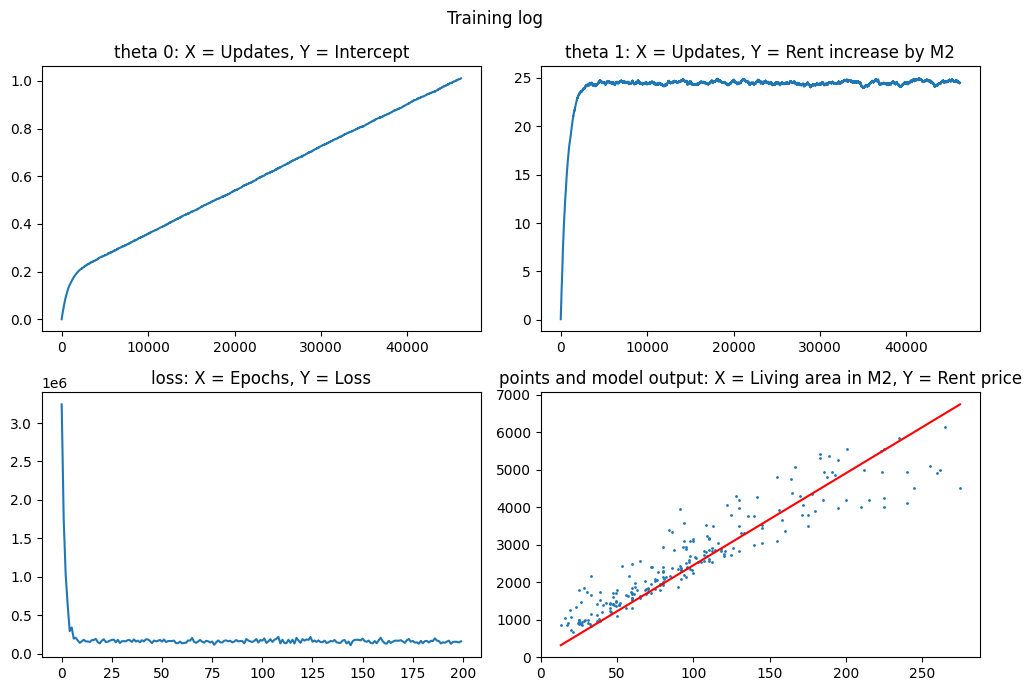

In [20]:
alpha = 0.0000001     # learning rate
epochs = 200          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 -alpha * theta_0.grad_v   # update rule for theta_0
        t1 = t1 - alpha * theta_1.grad_v  # update rule for theta_1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)

# losses rmse mae mape
rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)

print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{100*mape:.1f}%")

plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** TO COMPLETE
# Further loss measures
In included the output of RMSE, MAE and MAPE loss into all outputs, this makes comparisions to the baseline easyer
With the additional loss measures now included, we can quicker estimate if the next model becomes better or worse than the previous. This will especially help and identifying wether a different setting increases or decreases the model quality by small amounts compared to the previous setting or the base line. For example for the last used model with initial parameters we get these outputs now

Values of first training:
* intercept (theta_0): 657.6890591150313
* slope (theta_1)    : 19.661179947454315
* The total value of the loss is 104915.13056913581
* The total value of the RMSE loss is 458
* The total value of the MAE loss is 347
* The total value of the MAPE loss is 14.6%
    * ![Regression Plot 1](../images/Regression1.png)


The values of the second training using computational graph, MSELossNode are at:
* intercept (theta_0): 1.0096547268272877
* slope (theta_1)    : 24.468826020044848
* The total value of the loss is 163446.95983227517
* The total value of the RMSE loss is 572
* The total value of the MAE loss is 414
* The total value of the MAPE loss is 17.4%

    * ![Regression Plot 2](../images/Regression2.png)
- Evolution of the loss:
As seen in the graph bottom left, the loss starts high, but stabilizes faster after around 10 epochs. This shows that the gradient descent works. The model quickly learns quite a lot of the datasets characteristic slope.
-

- Evolution of theta_1: Theta 1 rises quickly and stabilizes at around 25. Thus the model quickly learns the relationship between living area and rent price. However, as we can see the regression line is starting to low, and is to steep, this can be seen especially well when comparing it to the line of the first plot.
- Evolution of theta_0: Theta 0 is rising only very slowly, as seen in top left plot, the value only rises up to about 1.009 after 200 epochs. This intercept is very low compared to the one in the first training which is at 657.68. Looks like the training almost only updates the Parameter Theta 0.

- General Assessment: The computational graph returns an ok result, but is also quite off compared to the more optimal regression line we get from the first training. Its slop is currently to steep and the intercept to low.


### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm. The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

intercept (theta_0): 1.59801935081206
slope (theta_1)    : 24.45246142024655
The total value of the loss is 163351.10336665716
The total value of the RMSE loss is 572
The total value of the MAE loss is 414
The total value of the MAPE loss is 17.4%


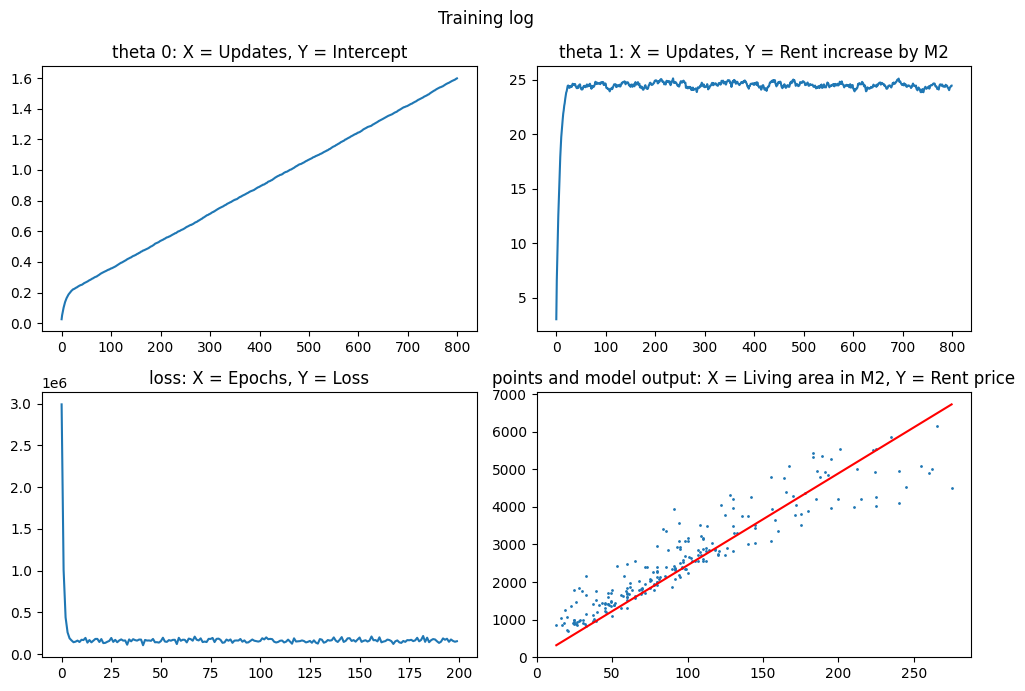

In [25]:
alpha = 0.00001  # learning rate can be higher than in the plain vanilla SGD
                  # as we will average the gradients over a batch of samples
epochs = 200
batch_size = 64
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        for batch in range(batch_size):
            n = random.choice(range(0, N))  # random sampling in the training set

            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            # batch grad instead of directly loss
            batch_grad_t0 += theta_0.grad_v   # update rule for theta_0
            batch_grad_t1 += theta_1.grad_v  # update rule for theta_1
            batch_loss += j.v

        #gradient average over batch of both gradients
        average_gradt0 = batch_grad_t0 / batch_size
        average_gradt1 = batch_grad_t1 / batch_size

        # apply learning rate
        t0 = t0 - alpha * average_gradt0
        t1 = t1 - alpha * average_gradt1
        # calcualte epoch loss with average of batch
        epoch_loss += batch_loss / batch_size

        t0_evolution.append(t0)
        t1_evolution.append(t1)


    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0


print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)

# losses rmse mae mape
rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)

print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{100*mape:.1f}%")

plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**
* intercept (theta_0): 0.46945848878424773
* slope (theta_1)    : 24.538756602881726
* The total value of the loss is 163528.34961511858
* The total value of the RMSE loss is 572
* The total value of the MAE loss is 413
* The total value of the MAPE loss is 17.3%
* ![Regression Plot 3](../images/Regression_LR_000001_b_32.png)

- Evolution of theta_0 and theta_1: theta 0 (top left) is evolving a worse than in the previous sample. It reaches only 0.47 which is half of the previous code, and going the wrong direction. . The Theta 1 (top right) is still converging at around 24.5. However it is still off by around 5 compared to the better 19.7 of the first training.
- Do we still have the same observation as in the plain stochastic version regarding the convergence of theta_1 and the slow evolution of theta_0 ? yes. Theta 0 ist still evolving slowly, even worse than in the base line, its now only going up to .47 ,So worse than previous code, and way off the base line value. Also Theta 1 is still converging at around 25, instead of around 20.
- Can we use larger learning rates than in the plain stochastic version ? Well, lets try changing the setting.
* ![Regression Plot 4](../images/Regression_LR_00001_b_32.png)

- The above code runs on 0.00001 , with is 100 times higher than the previous 0.0000001 model, and 10 times higher than initial setting at Batch
* intercept (theta_0): 3.044435389362943
* slope (theta_1)    : 24.281332213244717
* The total value of the loss is 163397.59090400883
* The total value of the RMSE loss is 572
* The total value of the MAE loss is 418
* The total value of the MAPE loss is 17.6%
* Both intercept and slope improved, the intercept (0.47 to 3.04) more than the slope (24.5 to 24.3)


- Another try with LR of 0.0001 , returned quite nice Theta 0, while Theta 1 became very unstable
- Going to 000005, further increases instability of Theta 1, while Theta 0 slightly improves
-
* ![Regression Plot 5](../images/Regression_LR_0001_b_32.png)
* intercept (theta_0): 28.00022002640483
* slope (theta_1)    : 24.39320418640355
* The total value of the loss is 158755.58424119971
* The total value of the RMSE loss is 563
* The total value of the MAE loss is 403
* The total value of the MAPE loss is 16.7%
* Especially the graph shows that the training is not stable. The loss shows many updates, and the slope is not stabilising on the later epochs and continues jittering very hard. This Learning rate is to high
- Finally setting LR of 0.00001 and batch_size 64, is further increasing the instability in Theta 1, but also improves Theta 0 compared to the first regression model
* ![Regression Plot 0.00001 batchsize 64](../images/Regression_LR_00001_b_64.png)
* intercept (theta_0): 1.59801935081206
* slope (theta_1)    : 24.45246142024655
* The total value of the loss is 163351.10336665716
* The total value of the RMSE loss is 572
* The total value of the MAE loss is 414
* The total value of the MAPE loss is 17.4%
* The higher batch size is again lowering the intercept. While it was reaching 3.04 with the same learning rate and batchsize 32, it is now only reaching 1.60, but the slope is almost the same as with 32 batch at 24.45

Summary:
- Yes much higher learning rates are possible with the batched gradient descent. The setting used in the beginning was higher by a factor 10, (0.000 001 to  0.000 000 1) and it was still stable and getting better till Learning rate of 0.000 01, which is 100 times higher than the initial setting. When getting to 1'000 times higher than initial the values seem to be getting better, however they are no longer stable

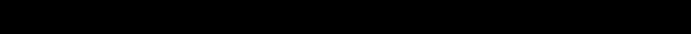
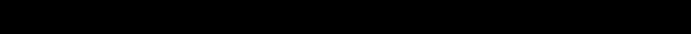

## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a larger learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.

intercept (theta_0): 275.6370532429447
slope (theta_1)    : 22.472795846041357
The total value of the loss is 124722.99617105773
The total value of the RMSE loss is 499
The total value of the MAE loss is 343
The total value of the MAPE loss is 12.9%


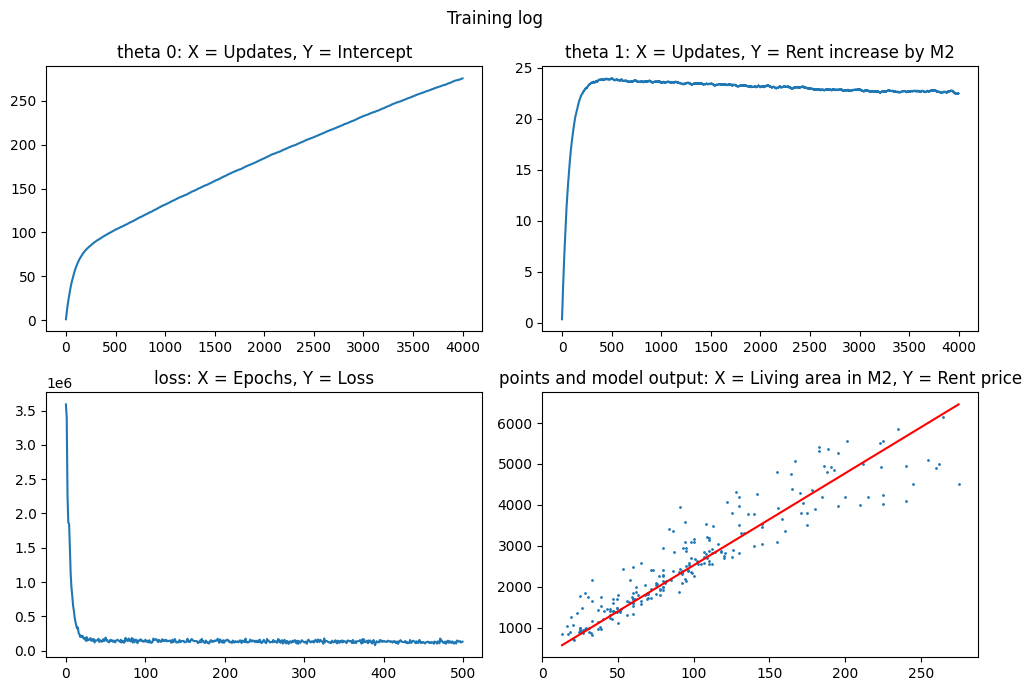

In [31]:
alpha_t0 = 0.0004    # learning rate for theta_0
alpha_t1 = 0.000001  # learning rate for theta_1
epochs = 500          # number of epochs (an epoch is a loop over the whole training set)

# This requires the same code as before, but at the update we use individual alphas to and t1
# removed alpha and epochs setting from batch code
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        for batch in range(batch_size):
            n = random.choice(range(0, N))  # random sampling in the training set

            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            # batch grad instead of directly loss
            batch_grad_t0 += theta_0.grad_v   # update rule for theta_0
            batch_grad_t1 += theta_1.grad_v  # update rule for theta_1
            batch_loss += j.v

        #gradient average over batch of both gradients
        average_gradt0 = batch_grad_t0 / batch_size
        average_gradt1 = batch_grad_t1 / batch_size

        # apply learning rate
        # only these next two lines change for different learning rates per theta 1 and 0
        t0 = t0 - alpha_t0 * average_gradt0
        t1 = t1 - alpha_t1 * average_gradt1
        # calcualte epoch loss with average of batch
        epoch_loss += batch_loss / batch_size

        t0_evolution.append(t0)
        t1_evolution.append(t1)


    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0


print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)

# losses rmse mae mape
rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)

print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{100*mape:.1f}%")

plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)



**Your observations**. To be completed
* **Initial setting, Learning rates: 0.0000001 and 0.00025**
* intercept (theta_0): 466.52464822545
* slope (theta_1)    : 21.07677409085386
* The total value of the loss is 109873.93961110595
* The total value of the RMSE loss is 469
* The total value of the MAE loss is 331
* The total value of the MAPE loss is 12.6%
* ![Regression Plot 0.0000001 and 0.00025](../images/Regression_LR_0000001_00025_b_32.png)
* This training now shows a better MAPE than the base line, however the intercept is still lower, and the slope higher than the base line.

* **Higher Learningrates: 0.000001 and 0.0025**
* intercept (theta_0): 1110.9480943916249
* slope (theta_1)    : 15.530271651736092
* The total value of the loss is 136823.01607699864
* The total value of the RMSE loss is 523
* The total value of the MAE loss is 423
* The total value of the MAPE loss is 21.3%
* * ![Regression Plot  0.000001 and 0.0025](../images/Regression_LR_000001_0025_b_32.png)
* This setting was to strong, the intercept was beeing updated to fast and overshot the base line value, later it was moving down, but the base line was not reached.
* Overall the MAPE indicates less points are matched
* Especially in the plot one can see that the regression line is not nicely matting the lower left quadrant
*
* **Medium t0 Learningrates: 0.000001 and 0.0005**
* intercept (theta_0): 722.8817563820937
* slope (theta_1)    : 19.063735957783443
* The total value of the loss is 105580.19687455418
* The total value of the RMSE loss is 460
* The total value of the MAE loss is 355
* The total value of the MAPE loss is 15.4%
* * ![Regression Plot  0.000001 and 0.0025](../images/Regression_LR_000001_0005_b_32.png)
* The intercept is now much closer to the base line, however the MAPE indicates that this model is performing slightly worse compared to the first setting with different learning rates

**My Summary**
* Evolution of Theta 0, (Top left): Theta 0 converged much faster, with my third setting with the medium learning rate for the intercept even to better values as compared to the first 2 learning rates setting
* Evolution of Theta 1, (Top right): Theta 1 got closer to the base line, however a to high learning rate for Theta0 moved it again away from the baseline. This setting however allows to further increase the learning rates
* General Observation regarding training: The higher learningrates imporove the intercept further while the slope did not benefit in the same way from increasing the learning rate. The second setting actually has a bit steeper slope, which is a little further off compared to the first setting. But its Intercept is closer to the Initial First Training.
* Further tries with 2 learning rates further finetuning them could result into further improvements of the results
* **at Learning Rates: **
* intercept (theta_0): 275.6370532429447
* slope (theta_1)    : 22.472795846041357
* The total value of the loss is 124722.99617105773
* The total value of the RMSE loss is 499
* The total value of the MAE loss is 343
* The total value of the MAPE loss is 12.9%
* * * ![Regression Plot  0.00001 and 0.004](../images/Regression_LR_00001_0004_b_32.png)
* The MAPE was further reduces, however the intercept is now lower than before, while the slope increased.
* This is visualy less in the middle of the data points in lower left quadrant
* One could further improve the MAPE with better Learning rate adjustments, but this would be manual overfitting to the existing data.



### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called *momentum* that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with gradients that are not always in the same direction. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

intercept (theta_0): 372.41148062046864
slope (theta_1)    : 21.99947530430137
The total value of the loss is 116304.58139186146
The total value of the RMSE loss is 482
The total value of the MAE loss is 332
The total value of the MAPE loss is 12.4%


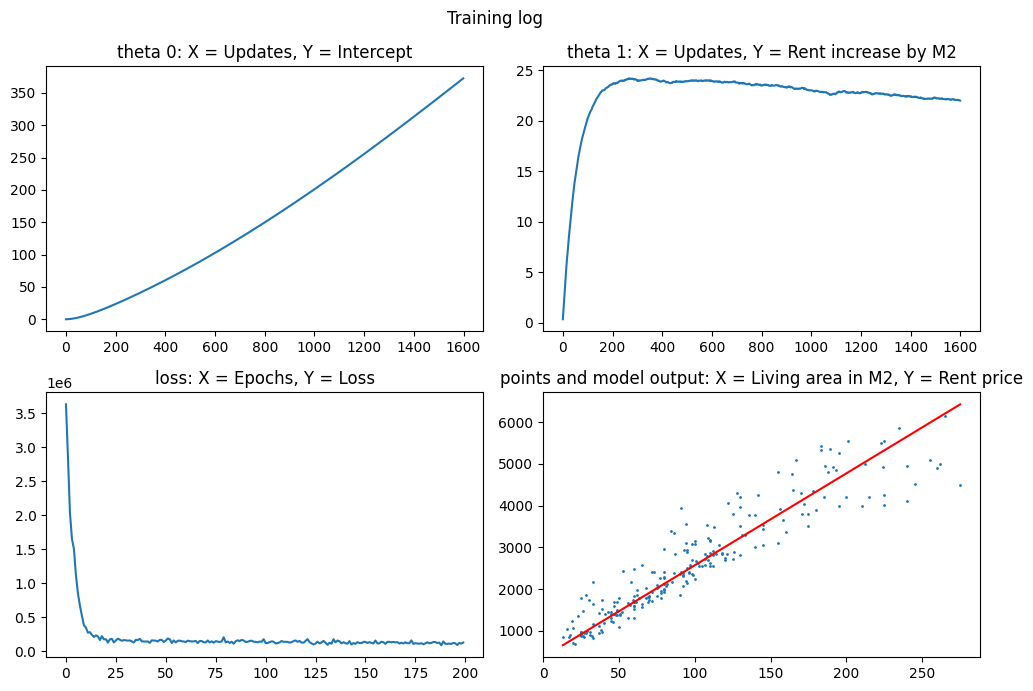

In [38]:
alpha = 0.0000001     # learning rate
beta_momentum_t0 = 0.9999     # momentum factor for theta_0
beta_momentum_t1 = 0.25000     # momentum factor for theta_1

epochs = 400          # number of epochs (an epoch is a loop over the whole training set)

# Two momentum status variables
momentum_t0 = 0.0
momentum_t1 = 0.0

# I am using the batch processing code as a basis and then adapt it
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD
                  # as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        for batch in range(batch_size):
            n = random.choice(range(0, N))  # random sampling in the training set

            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            # batch grad instead of directly loss
            batch_grad_t0 += theta_0.grad_v   # update rule for theta_0
            batch_grad_t1 += theta_1.grad_v  # update rule for theta_1
            batch_loss += j.v

        #gradient average over batch of both gradients
        average_gradt0 = batch_grad_t0 / batch_size
        average_gradt1 = batch_grad_t1 / batch_size

        # apply learning rate with momentum and momentum state variable
        # First calculate the momentum , including the average_grad_to/t1 from batch processing
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * average_gradt0
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * average_gradt1

        # remove momentum from parameters instead of directly the alpha
        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1

        # calcualte epoch loss with average of batch
        epoch_loss += batch_loss / batch_size

        t0_evolution.append(t0)
        t1_evolution.append(t1)


    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0


print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)

# losses rmse mae mape
rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)

print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{100*mape:.1f}%")

plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)


**Reminder, the Base Line**
* intercept (theta_0): 657.6890591150313
* slope (theta_1)    : 19.661179947454315
* The total value of the loss is 104915.13056913581
* The total value of the RMSE loss is 458
* The total value of the MAE loss is 347
* The total value of the MAPE loss is 14.6%


**Analysis**
* ![Regression Plot LR 0.0000001 and Momentum 0.999 and 0.5](../images/Regression_LR_0000001_Momentum_9999_5_b_32.png)
* intercept (theta_0): 319.26445123849794
* slope (theta_1)    : 22.40110804553587
* The total value of the loss is 120828.83340534591
* The total value of the RMSE loss is 492
* The total value of the MAE loss is 337
* The total value of the MAPE loss is 12.6%
* **Learningrate 0.0000001 , Momentum Theta 0 : 0.999 , Momentum Theta 1: 0.5**
* **Evolution of Theta 0, Top Left**: Theta 0 the intercept rises slowly to about 319.3. This is better than the only batch implementation, but is  below the base line.
* **Evolution of Theta 1, Top Left**: Theta 1, rises fast till it reaches around 24, and then slowly decreases till it reaches the final value of 22.40
* **General Observation**: The Momentum is able to provide better results than the base line, when comparing the MAPE, and MAE, however the intercept still is a little low compared to the base line. . Some fine tuning may allow to get even better results. My guess would be to increase the momentum of Theta 0 further, and first keep Theta 1 at the initial value. Maybe later try to optimize Theta 1 so that the training results get closer to the first training values
* **Plots of further tries**
* Increasing the Momentum over 1 breaks the algorithm, resulting in:
* C:\Users\rolan\AppData\Local\Temp\ipykernel_46520\2775558507.py:41: RuntimeWarning: overflow encountered in scalar add
  batch_loss += j.v
* C:\Users\rolan\PycharmProjects\pythonProject\venvDeLearn\DeLearnSpr26\Mandatory_Handin2\student-input\cgnodes.py:413: RuntimeWarning: overflow encountered in scalar power
  loss = 0.5 * (y_hat - y)**2
* C:\Users\rolan\PycharmProjects\pythonProject\venvDeLearn\DeLearnSpr26\Mandatory_Handin2\student-input\cgnodes.py:258: RuntimeWarning: overflow encountered in scalar multiply
  self.parents[0].backward(grad_z * x2_val)RuntimeWarning: overflow encountered in square
  Sum = np.sum((y_hat - y)**2)
* intercept (theta_0): 8.169938435193451e+279
* slope (theta_1)    : -2.3996849688564045e+276
* The total value of the loss is inf

* **Increase Momentum Theta1 to 0.75**
* ![Regression Plot LR 0.0000001 Momentum 0.9999 and 0.75](../images/Regression_LR_0000001_Momentum_9999_75_b_32.png)
* Adapting the Momentum of Theta 1, has no big influence on the resulting model, as Theta 1 is already good in the initial setting 0.5, when changing e.g. to 0.75 the intercept is negatively affected and the theta 0 which in turn becomes lower. The loss is staying around the same level. However, the intercept is now again lower, which is the oposite reaction of what we want to have.
* intercept (theta_0): 261.7776139414738
* slope (theta_1)    : 22.557811672601
* The total value of the loss is 126191.4946351978
* The total value of the RMSE loss is 502
* The total value of the MAE loss is 346
* The total value of the MAPE loss is 13.0%

* * * ![Regression Plot LR 0.0000001 Momentum 0.9999 and 0.25](../images/Regression_LR_0000001_Momentum_9999_25_b_32.png)
* intercept (theta_0): 372.41148062046864
* slope (theta_1)    : 21.99947530430137
* The total value of the loss is 116304.58139186146
* The total value of the RMSE loss is 482
* The total value of the MAE loss is 332
* The total value of the MAPE loss is 12.4%
* * Lowering the Momentum of Theta 1 to 0.25 has the effect of a higher intercept, which is good compared to the first training which we would like to get closer to. And the total loss is also lower, however the resulting slope is again a little closer to the baseline which is positive.


* **Summary**
* The Momentum, same as the previous adaption of two different learning rates provides very good MAPE values
* The Momentum further increases those values, while we are not exactly reaching the base lines slope and intercept, we reached an overall better graph.
* However having the graph not only match the lower or upper quadrants better would be preferable. However this requires a not linear regression
* Also here, having the individual momentums for both Thetas, shows a good effect on beeing able to adapt both slope and intercept individually

# Summary regarding Optimizers
* Batch Gradient descent
* Batch Gradient descent with different Learning Rates
* Batch Gradient descent with Momentum
* Experiments were run  with batch sizes in Batch gradient descent, showing that the batch size positively affects the training results
* Batch: Adding this improved the intercept, when increasing the batch size, however negated the positive effect reached by batch processing
* Batch with different Learning Rates: This showed a strong effect on Theta 0 in all experiments. With a Learning rate up to 0.0025 for Theta 0, the value was rising up to 1111, this is however to high compared to our reference model. This however shows the great effect this method can have. However in a more complex environment manually adapting many different Theta 1-n is not feasible
* Batch with Momentum: Only adapting the Momentum, this showed some limits, as with the maximum possible momentum of 0.9999, just below 1, the intercept was still only at around 319 rather than 657. And when changing the Theta 1 Momentum from 0.5 to a higher value, the intercept would go down. However further lowering the momentum for Theta 1 had a influence on Theta 0, allowing the intercept to become higher again.
* Conclusion, with the optimizing algorithm the goal of reaching the base line became reachable, and in some extend the metrics applied such as MAPE show that the models are explaining more of the data.
* Further combining the methods could provide an even better result than the base line. When combining batch processing with variable learning rates and momentum. However could also become more unstable and eventually more complex to finetune.

## Optional objectives

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- Investigate the use of 2nd order model instead of the simple linear model.
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam.
- Implement an early stopping strategy in your training loop.
- Implement a \textit{Learning Rate Decay on Plateau} strategy in the training loop.
- Normalize the input data with a zero norm approach and compare to your experiments without normalization.


# Optional implementation : Early Stopping
According to our slides we describe it with:
Idea:
* Stop training when validation error does not
improve anymore.
* **Algorithm**
* Run optimisation algorithm to train the model -
compute validation error.
* Store copy of parameters of latest best model
(with minimal validation error).
* Iterate until validation error stops improving
(e.g. has not improved for k steps).
• Return parameters where the smallest
validation error could be observed.
* **Implementation**
* Further variables needed,
* waiting time as epochs,
* minimum error improvement,
* best loss,
* a counter for epochs without minumum improvement
* Compare each update to the minimum error, if below increment counter
* When counter for epochs without minimum improvement is reached stop training

So Gerard I suspect you have a good reason for pulling me away from my duties, at epoch::  53
Your wodka can wait Yuri, losses are at::  117495.44633962057
Come stand here, you need to see this
I know all about the Zerg General!
intercept (theta_0): 50.4858466289435
slope (theta_1)    : 24.104667314875226
The total value of the loss is 154960.5092909175
The total value of the RMSE loss is 557
The total value of the MAE loss is 399
The total value of the MAPE loss is 16.4%


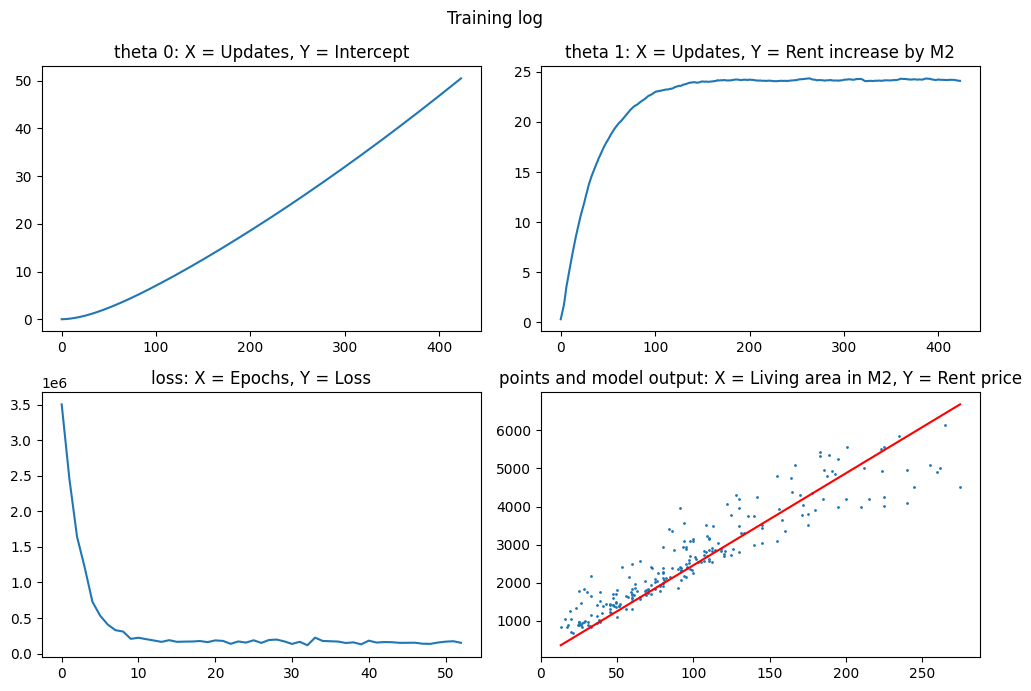

In [43]:
# Implementation of early stopping, using Momentum
# Using Momentum code as a base, as this showed best results up to here
beta_momentum_t0 = 0.9999     # momentum factor for theta_0
beta_momentum_t1 = 0.5000     # momentum factor for theta_1

# Two momentum status variables
momentum_t0 = 0.0
momentum_t1 = 0.0

# I am using the batch processing code as a basis and then adapt it
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD
                  # as we will average the gradients over a batch of samples
#Epochs changed to 500, from now on, not changed in previous codes
epochs = 500
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

# New variables for early stopping
waitfor = 20
minimumImprovement = 0.001
bestLoss = float("inf")
noImprovementCounter = 0




loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        for batch in range(batch_size):
            n = random.choice(range(0, N))  # random sampling in the training set

            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            # batch grad instead of directly loss
            batch_grad_t0 += theta_0.grad_v   # update rule for theta_0
            batch_grad_t1 += theta_1.grad_v  # update rule for theta_1
            batch_loss += j.v

        #gradient average over batch of both gradients
        average_gradt0 = batch_grad_t0 / batch_size
        average_gradt1 = batch_grad_t1 / batch_size

        # apply learning rate with momentum and momentum state variable
        # First calculate the momentum , including the average_grad_to/t1 from batch processing
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * average_gradt0
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * average_gradt1

        # remove momentum from parameters instead of directly the alpha
        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1

        # calcualte epoch loss with average of batch
        epoch_loss += batch_loss / batch_size

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    current_loss = epoch_loss / n_steps
    loss_evolution.append(current_loss)
    epoch_loss = 0.0
    if current_loss < bestLoss - minimumImprovement:
        bestLoss = current_loss
        noImprovementCounter = 0
    else:
        noImprovementCounter += 1
    if noImprovementCounter >= waitfor:
        print("So Gerard I suspect you have a good reason for pulling me away from my duties, at epoch:: ",epoch+1)
        print("Your wodka can wait Yuri, losses are at:: ",bestLoss)
        print("Come stand here, you need to see this")
        print("I know all about the Zerg General!")
        break

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)

# losses rmse mae mape
rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)

print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{100*mape:.1f}%")

plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)



# Early stopping
* **First try**
* So Gerard I suspect you have a good reason for pulling me away from my duties, at epoch 20
* Your wodka can wait Yuri, losses are at inf
* Come stand here, you need to see this
* I know all about the Zerg General!
* intercept (theta_0): 13.527058695760045
* slope (theta_1)    : 24.02662029363891
* The total value of the loss is 162283.78074901403
* The total value of the RMSE loss is 570
* The total value of the MAE loss is 419
* The total value of the MAPE loss is 17.6%
* * ![Early Stopping, but errorous](../images/EarlyStopping_1.png)


* **Clearly, according to the graphis, early stopping stopped to soon**
* However even looking at the epoch it stopped at, gives us a hint that the code does not work as intented, as it is stopping after 20 epochs rather than 20 epochs after no reasonable updates happened
* **Second try and error identification**
* Error was:      if bestLoss < current_loss - minimumImprovement:
* My stopping logic was the wrong way around, it should be current_loss < best_Loss - minimum
* The first way, it would not check for the current loss beeing smaller than the currently best, neither for the minimum improvement currently
* Correct is:     if current_loss < bestLoss - minimumImprovement:
* This returns us:
* So Gerard I suspect you have a good reason for pulling me away from my duties, at epoch::  53
* Your wodka can wait Yuri, losses are at::  117495.44633962057
* Come stand here, you need to see this
* I know all about the Zerg General!
* intercept (theta_0): 50.4858466289435
* slope (theta_1)    : 24.104667314875226
* The total value of the loss is 154960.5092909175
* The total value of the RMSE loss is 557
* The total value of the MAE loss is 399
* The total value of the MAPE loss is 16.4%
* * * ![Early Stopping, Second try works fine](../images/EarlyStopping_2.png)
## Implementation Summary
* It's important to do correct comparisions!
* Its also important to use Starcraft Broodwar texts correctly
* Furthermore, this check is very simple but saved us 447 epochs of training in the second case.
* It only requires a few variables at the beginning, then saving the current loss and checking if the previous loss was giving a meaningful update
* One could fine tune this algorithm, but I am fine with the basic version and settings
* Also the suggested link in the slides indicates a whole class to be created. For simplicity and speed I am fine using just some if/else checks

# Optional implementation : Learning Rate Decay
* According to slides of Week 5, Benefits of depth, Learning rate can be resuced with a sheduler torch.optim.lr_scheduler
* However, we are not using torch here and should reimplement a simpler method ourselves
* Thus I will implement the following:

* **Algorithm**
* Run oncrement counter
* When counter for epochs without minimum improvement is reached stop training

Learning rate reduced from:  1e-06  to:  5e-07  at epoch  37
Learning rate reduced from:  5e-07  to:  2.5e-07  at epoch  45
Learning rate reduced from:  2.5e-07  to:  1.25e-07  at epoch  69
Learning rate reduced from:  1.25e-07  to:  6.25e-08  at epoch  81
Learning rate reduced from:  6.25e-08  to:  3.125e-08  at epoch  89
Learning rate reduced from:  3.125e-08  to:  1.5625e-08  at epoch  97
Learning rate reduced from:  1.5625e-08  to:  7.8125e-09  at epoch  105
Learning rate reduced from:  7.8125e-09  to:  3.90625e-09  at epoch  113
Learning rate reduced from:  3.90625e-09  to:  1.953125e-09  at epoch  126
Learning rate reduced from:  1.953125e-09  to:  9.765625e-10  at epoch  134
Learning rate reduced from:  9.765625e-10  to:  4.8828125e-10  at epoch  142
Learning rate reduced from:  4.8828125e-10  to:  2.44140625e-10  at epoch  150
Learning rate reduced from:  2.44140625e-10  to:  1.220703125e-10  at epoch  158
Learning rate reduced from:  1.220703125e-10  to:  1e-10  at epoch  166


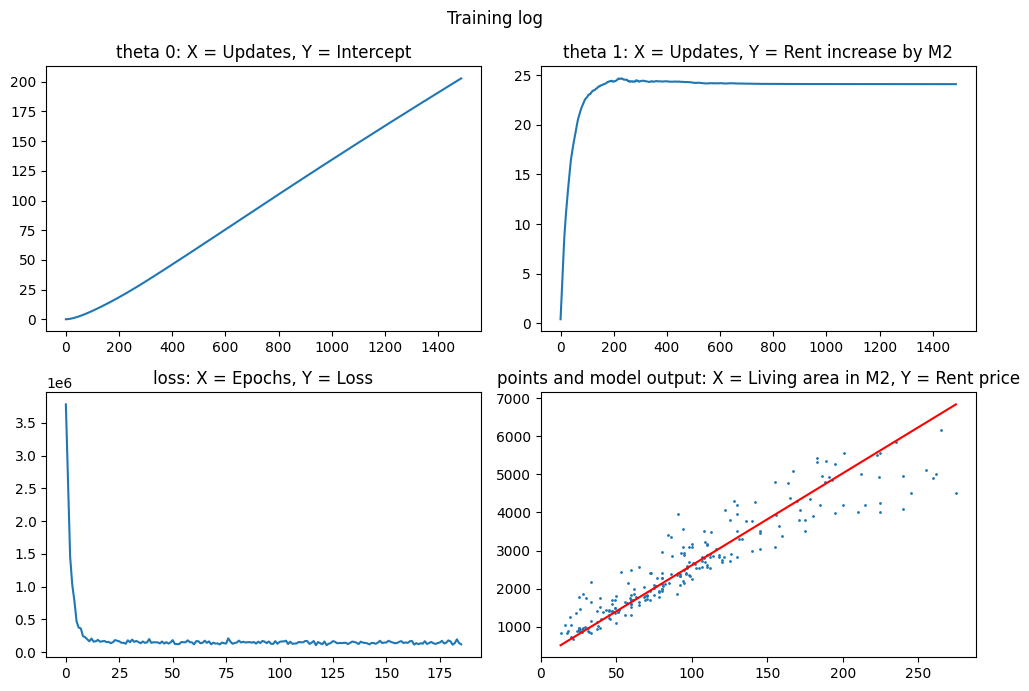

In [50]:
# Implementation of early stopping, using Momentum
# Using Momentum code as a base, as this showed best results up to here
beta_momentum_t0 = 0.9999     # momentum factor for theta_0
beta_momentum_t1 = 0.5000     # momentum factor for theta_1

# Two momentum status variables
momentum_t0 = 0.0
momentum_t1 = 0.0

# I am using the batch processing code as a basis and then adapt it
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD
                  # as we will average the gradients over a batch of samples
#Epochs changed to 500, from now on, not changed in previous codes
epochs = 500
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

# New variables for early stopping
waitfor = 20
minimumImprovement = 0.001
bestLoss = float("inf")
noImprovementCounter = 0

# new variables for Learning Rate Decay
LrWaitTime = 8 # How many epochs we wait
Lr_decaying = 0.5 # By which factor are the learning rates decreased
minimumLr = 1e-10 # means 0.000 000 0001
NoLRImprovementCounter = 0 # A counter to check for LR improvements


loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        for batch in range(batch_size):
            n = random.choice(range(0, N))  # random sampling in the training set

            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            # batch grad instead of directly loss
            batch_grad_t0 += theta_0.grad_v   # update rule for theta_0
            batch_grad_t1 += theta_1.grad_v  # update rule for theta_1
            batch_loss += j.v

        #gradient average over batch of both gradients
        average_gradt0 = batch_grad_t0 / batch_size
        average_gradt1 = batch_grad_t1 / batch_size

        # apply learning rate with momentum and momentum state variable
        # First calculate the momentum , including the average_grad_to/t1 from batch processing
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * average_gradt0
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * average_gradt1

        # remove momentum from parameters instead of directly the alpha
        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1

        # calcualte epoch loss with average of batch
        epoch_loss += batch_loss / batch_size

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    current_loss = epoch_loss / n_steps
    loss_evolution.append(current_loss)
    epoch_loss = 0.0

    #Early Stopping implementation, check if if applies
    if current_loss < bestLoss - minimumImprovement:
        bestLoss = current_loss
        noImprovementCounter = 0
        # Added counter for LR decay
        NoLRImprovementCounter = 0
    else:
        noImprovementCounter += 1
        # Added counter for LR decay
        NoLRImprovementCounter += 1

    # Learning Rate decay check
    if NoLRImprovementCounter >= LrWaitTime:
        old_Lr = alpha
        if old_Lr > minimumLr:
            alpha = max(alpha * Lr_decaying,minimumLr)
            NoLRImprovementCounter = 0
            noImprovementCounter = 0
            print("Learning rate reduced from: ",old_Lr," to: ",alpha," at epoch ",epoch+1)


    # now realy early stop if you must
    if noImprovementCounter >= waitfor:
        print("So Gerard I suspect you have a good reason for pulling me away from my duties, at epoch:: ",epoch+1)
        print("Your wodka can wait Yuri, losses are at:: ",bestLoss)
        print("Come stand here, you need to see this")
        print("I know all about the Zerg General!")
        break

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)

# losses rmse mae mape
rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)

print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{100*mape:.1f}%")

plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)



# Learning Rate Decay:
**First try**
```python
Learning rate reduced from 1e-06 to 5e-07
Learning rate reduced from 5e-07 to 2.5e-07
Learning rate reduced from 2.5e-07 to 1.25e-07
Learning rate reduced from 1.25e-07 to 6.25e-08
Learning rate reduced from 6.25e-08 to 3.125e-08
Learning rate reduced from 3.125e-08 to 1.5625e-08
So Gerard I suspect you have a good reason for pulling me away from my duties, at epoch::  84
Your wodka can wait Yuri, losses are at::  114575.25571505718
Come stand here, you need to see this
I know all about the Zerg General!
intercept (theta_0): 82.85127354144453
slope (theta_1)    : 24.22594036159932
The total value of the loss is 150404.1783044272
The total value of the RMSE loss is 548
The total value of the MAE loss is 383
The total value of the MAPE loss is 15.4%
```
* * ![Learning Rate Decay, first errorous](../images/Learning_RateDecay.png)


* However, the first code, did not reset the early stopping counter uppon changing the LearningRate,
* Two improvements to be done 1: Output at which epoch the LR was adapte , 2: Update the early stopping counter to 0 when LR is adapted
* **Second try**
* The following prints indicate that my function which is supposed to calculate the new learning rate, in fact ignores the set minimum learning rate,
* therefor i need to fix my code at ::

```python
    # Learning Rate decay check
    if NoLRImprovementCounter >= LrWaitTime:
        old_Lr = alpha
        alpha = max(alpha * Lr_decaying,minimumLr)
        NoLRImprovementCounter = 0
        noImprovementCounter = 0
        print("Learning rate reduced from: ",old_Lr," to: ",alpha," at epoch ",epoch+1)
```

* I have the following debug output at run 2, , after Epoc 143, the Learning Rate was on the minimum value, but updates were still performed, they should have been stopped then, as from 1e-10 to 1e-10 is not an update
* Prints:
```python
Learning rate reduced from:  1e-06  to:  5e-07  at epoch  24
Learning rate reduced from:  5e-07  to:  2.5e-07  at epoch  35
Learning rate reduced from:  2.5e-07  to:  1.25e-07  at epoch  55
Learning rate reduced from:  1.25e-07  to:  6.25e-08  at epoch  63
Learning rate reduced from:  6.25e-08  to:  3.125e-08  at epoch  71
Learning rate reduced from:  3.125e-08  to:  1.5625e-08  at epoch  79
Learning rate reduced from:  1.5625e-08  to:  7.8125e-09  at epoch  87
Learning rate reduced from:  7.8125e-09  to:  3.90625e-09  at epoch  95
Learning rate reduced from:  3.90625e-09  to:  1.953125e-09  at epoch  103
Learning rate reduced from:  1.953125e-09  to:  9.765625e-10  at epoch  111
Learning rate reduced from:  9.765625e-10  to:  4.8828125e-10  at epoch  119
Learning rate reduced from:  4.8828125e-10  to:  2.44140625e-10  at epoch  127
Learning rate reduced from:  2.44140625e-10  to:  1.220703125e-10  at epoch  135
Learning rate reduced from:  1.220703125e-10  to:  1e-10  at epoch  143
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  151
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  159
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  167
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  175
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  183
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  191
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  199
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  207
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  215
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  223
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  231
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  239
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  247
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  255
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  263
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  273
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  281
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  289
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  297
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  305
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  313
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  321
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  329
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  337
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  345
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  353
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  361
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  369
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  377
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  385
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  393
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  401
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  409
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  417
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  425
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  433
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  441
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  449
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  457
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  465
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  473
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  481
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  489
Learning rate reduced from:  1e-10  to:  1e-10  at epoch  497
intercept (theta_0): 457.9331677169316
slope (theta_1)    : 24.210184253321
The total value of the loss is 173134.07383076975
The total value of the RMSE loss is 588
The total value of the MAE loss is 435
The total value of the MAPE loss is 17.6%
```

**After Another set of tries**
* Correct code now checking if the current learning rate is bigger than the minimum, and only then performs the update , prints and counter resets
* This results into excelent values for MAPE and other model metrics, first the code fixed
```python

    # Learning Rate decay check
    if NoLRImprovementCounter >= LrWaitTime:
        old_Lr = alpha
        if old_Lr > minimumLr:
            alpha = max(alpha * Lr_decaying,minimumLr)
            NoLRImprovementCounter = 0
            noImprovementCounter = 0
            print("Learning rate reduced from: ",old_Lr," to: ",alpha," at epoch ",epoch+1)
```
* Now the output after fixing the Learning Rate decay
* The MAPE reaches 13.6%
* The slope and intercept are not yet where we would want them to be, compared to the base line
* * * ![Learning Rate Decay, Final, correct](../images/Learning_RateDecay_Fixed.png)

```python
Learning rate reduced from:  1e-06  to:  5e-07  at epoch  37
Learning rate reduced from:  5e-07  to:  2.5e-07  at epoch  45
Learning rate reduced from:  2.5e-07  to:  1.25e-07  at epoch  69
Learning rate reduced from:  1.25e-07  to:  6.25e-08  at epoch  81
Learning rate reduced from:  6.25e-08  to:  3.125e-08  at epoch  89
Learning rate reduced from:  3.125e-08  to:  1.5625e-08  at epoch  97
Learning rate reduced from:  1.5625e-08  to:  7.8125e-09  at epoch  105
Learning rate reduced from:  7.8125e-09  to:  3.90625e-09  at epoch  113
Learning rate reduced from:  3.90625e-09  to:  1.953125e-09  at epoch  126
Learning rate reduced from:  1.953125e-09  to:  9.765625e-10  at epoch  134
Learning rate reduced from:  9.765625e-10  to:  4.8828125e-10  at epoch  142
Learning rate reduced from:  4.8828125e-10  to:  2.44140625e-10  at epoch  150
Learning rate reduced from:  2.44140625e-10  to:  1.220703125e-10  at epoch  158
Learning rate reduced from:  1.220703125e-10  to:  1e-10  at epoch  166
So Gerard I suspect you have a good reason for pulling me away from my duties, at epoch::  186
Your wodka can wait Yuri, losses are at::  106292.66493270977
Come stand here, you need to see this
I know all about the Zerg General!
intercept (theta_0): 202.87570980932836
slope (theta_1)    : 24.109084051430642
The total value of the loss is 140800.88845102134
The total value of the RMSE loss is 531
The total value of the MAE loss is 358
The total value of the MAPE loss is 13.6%
```


# Second Order / Polynomial Regression
